In [120]:
import cv2
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

In [121]:
path_image_1 = "/home/wesley/Desktop/JWST_REU/Jorgensen_2024/"
path_image_2 = "/home/wesley/Desktop/JWST_REU/HEFE_2025/"

In [ ]:
hdul_1 = fits.open((path_image_1 + 'Jorgensen_processed_2024_f212n.fits'))
hdul_2 = fits.open((path_image_2 + 'repro_processed_hefe_2025_F212N.fits'))
# hdul_2 = fits.open((path_image_2 + 'testing_dot_25km_in_3_years.fits'))


In [123]:
# HOPS 370
# fig, ax = plt.subplots(1, 1,figsize=(9, 9))
# im = ax.imshow(hdul_1[1].data, origin='lower', vmin=0, vmax=100, cmap='viridis', interpolation='none')

# ax.set_xlim([2227, 2673])
# ax.set_ylim([3929, 4476])
cut_hdu_1 = hdul_1[1].data[3929: 4476, 2227: 2673] - np.mean(hdul_1[1].data[3929: 4476, 2227: 2673])

In [124]:
# HOPS 66 star
# fig, ax = plt.subplots(1, 1,figsize=(9, 9))
# im = ax.imshow(hdul_1[1].data, origin='lower', vmin=0, vmax=100, cmap='viridis', interpolation='none')

# ax.set_xlim([4550, 4758])
# ax.set_ylim([5254, 6200])
# cut_hdu_1 = hdul_1[1].data[5254: 6200, 4550: 4758] - np.median(hdul_1[1].data[5254: 6200, 4550: 4758] )

In [125]:
# # # HOPS 66
# # fig, ax = plt.subplots(1, 1,figsize=(9, 9))
# # im = ax.imshow(hdul_1[1].data, origin='lower', vmin=0, vmax=100, cmap='viridis', interpolation='none')

# # ax.set_xlim([4550, 4758])
# # ax.set_ylim([5638, 6200])
# cut_hdu_1 = hdul_1[1].data[5638: 6200, 4550: 4758] - np.median(hdul_1[1].data[5638: 6200, 4550: 4758] )

In [126]:
flip_cut_1 = cut_hdu_1[::-1, :]

hdu = fits.PrimaryHDU(data=cut_hdu_1)
hdu.writeto(path_image_1 + "HOPS_370_Jorgensen.fits", overwrite=True)

In [127]:
# HOPS 370
# fig, ax = plt.subplots(1, 1,figsize=(9, 9))
# im = ax.imshow(hdul_2[1].data, origin='lower', vmin=0, vmax=100, cmap='viridis', interpolation='none')

# ax.set_xlim([2227, 2673])
# ax.set_ylim([3929, 4476])
cut_hdu_2 = hdul_2[1].data[3929: 4476, 2227: 2673] - np.mean(hdul_2[1].data[3929: 4476, 2227: 2673])

In [128]:
# HOPS 66
# fig, ax = plt.subplots(1, 1,figsize=(9, 9))
# im = ax.imshow(hdul_2[1].data, origin='lower', vmin=0, vmax=100, cmap='viridis', interpolation='none')

# ax.set_xlim([4550, 4758])
# ax.set_ylim([5638, 6200])
# cut_hdu_2 = hdul_2[1].data[5638: 6200, 4550: 4758] - np.median(hdul_2[1].data[5638: 6200, 4550: 4758] )

In [129]:
# HOPS 66 STAR
# fig, ax = plt.subplots(1, 1,figsize=(9, 9))
# im = ax.imshow(hdul_2[1].data, origin='lower', vmin=0, vmax=100, cmap='viridis', interpolation='none')

# ax.set_xlim([4550, 4758])
# ax.set_ylim([5254, 6200])
# cut_hdu_2 = hdul_2[1].data[5254: 6200, 4550: 4758] - np.median(hdul_2[1].data[5254: 6200, 4550: 4758] )

In [130]:
flip_cut_2 = cut_hdu_2[::-1, :]
hdu = fits.PrimaryHDU(data=cut_hdu_2)
hdu.writeto(path_image_2 + "HOPS_370_HEFE.fits", overwrite=True)

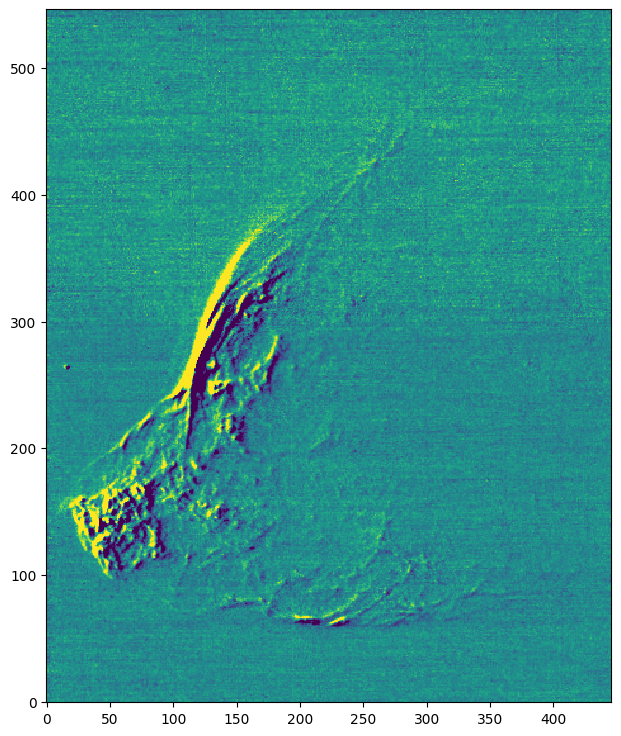

In [131]:
fig, ax = plt.subplots(1, 1,figsize=(9, 9))
im = ax.imshow(cut_hdu_2 - cut_hdu_1, origin='lower', vmin=-10, vmax=10, cmap='viridis', interpolation='none')

In [132]:
fits_1  = '/home/wesley/Desktop/JWST_REU/Jorgensen_2024/HOPS_370_Jorgensen.fits'
fits_2  = '/home/wesley/Desktop/JWST_REU/HEFE_2025/HOPS_370_HEFE.fits'

In [ ]:
def load_fits_as_uint8(path_or_array, pmin=1, pmax=99.5):
    if isinstance(path_or_array, str):
        with fits.open(path_or_array) as hdul:
            data = hdul[0].data.astype(np.float32)
    else:
        data = np.asarray(path_or_array, dtype=np.float32)

    data = np.nan_to_num(data, nan=np.nanmedian(data))

    # Flip vertically: FITS row 0 is the bottom of the image,
    # but image/video formats expect row 0 to be the top.
    data = data[::-1, :]

    lo, hi = np.percentile(data, [pmin, pmax])
    data = np.clip(data, lo, hi)
    data = (data - lo) / (hi - lo + 1e-12)
    return (data * 255).astype(np.uint8)

In [134]:
def frames_to_video(frame1, frame2, output_path="fits_pair.avi", fps=1):
    h, w = frame1.shape
    fourcc = cv2.VideoWriter_fourcc(*"MJPG")
    out = cv2.VideoWriter(output_path, fourcc, fps, (w, h), isColor=False)
    for k in range(3):
        out.write(frame1)
        out.write(frame2)
    out.release()
    print(f"Saved 2-frame video to {output_path}")

In [135]:
f1 = load_fits_as_uint8(fits_1)
f2 = load_fits_as_uint8(fits_2)
frames_to_video(f2, f1, "HOPS_370_long_fits_pair.avi")

Saved 2-frame video to HOPS_370_long_fits_pair.avi
